# Global Conflict Analysis: Descriptive Insights from 1979–2021
## First Notebook: Introduction

Understanding patterns of conflict and violence across countries is crucial for informing humanitarian action, international policy, and global development strategies. Analyzing these events provides insights into regions most affected by violence, the severity of conflicts, and how media attention correlates with actual events. This is particularly relevant as organizations, governments, and NGOs face growing challenges in resource allocation, crisis management, and monitoring global peace and security.

This analysis uses a global conflict events dataset spanning 1979–2021, containing detailed records of conflict events by country and year, including event types (FIGHT, ASSAULT, COERCE, etc.), event severity (`GoldsteinScale`), media coverage (`AvgNumMentions`), and average media tone (`AvgAvgTone`). It provides a comprehensive view of geopolitical tensions over more than four decades.

The study aims to answer key questions: which types of conflicts are most frequent and how their severity has evolved over time, what is the relationship between conflict severity and media coverage, and which countries or regions have been most affected by severe conflicts. The objective of this analysis is to perform a high-level exploratory assessment of global conflict data, identifying patterns, trends, and anomalies that can guide future, more detailed analyses aimed at generating actionable insights.

Analytical methods include advanced descriptive analytics with Python and visualization through interactive charts and maps with Tableau, highlighting patterns, trends, and critical regions.

**Author:** J-F Jutras  
**Date:** November 2025  
**Dataset:** Global Conflict Events Dataset – Kaggle


## 1.1-Data Loading and Overview

The dataset is retrieved directly from Kaggle using the kagglehub library. This ensures the analysis remains reproducible and uses the latest available version.

In [1]:
import pandas as pd
import os

dataset_dir = '/kaggle/input/gdelt-conflict-events-1979-2021'
csv_path = os.path.join(dataset_dir, 'gdelt_conflict_1_0.csv')

df = pd.read_csv(csv_path)

print(df.head(), "\n")
print(df.tail())

   Year CountryCode CountryName  SumEvents  TotalEvents  NormalizedEvents1000  \
0  1979          CH       China        350        33541             10.434990   
1  1979          HR     Croatia         14          714             19.607843   
2  1979          SU       Sudan         16         1354             11.816839   
3  1979          SY       Syria         71         3119             22.763706   
4  1979          GM     Germany         33         6615              4.988662   

   EventRootCode EventRootDescr  EventCode  \
0             19          FIGHT        193   
1             19          FIGHT        190   
2             17         COERCE        173   
3             19          FIGHT        193   
4             17         COERCE        172   

                                          EventDescr  GoldsteinScale  \
0            Fight with small arms and light weapons           -10.0   
1  Use conventional military force, not specified...           -10.0   
2       Arrest, deta

| Column Name           | Description                                                                                       |
|-----------------------|---------------------------------------------------------------------------------------------------|
| Year                  | Year of the events                                                                                 |
| CountryCode           | Country code                                                                                       |
| CountryName           | Country name                                                                                       |
| SumEvents             | Count of events by event code, year, and country                                                  |
| TotalEvents           | Total events by year and country according to the GDELT 1.0 normalization files                    |
| NormalizedEvents1000  | Proportion of events relative to the normalization total (over 1000), calculated as SumEvents/TotalEvents * 1000 |
| EventRootCode         | CAMEO event root code                                                                               |
| EventRootDescr        | CAMEO event root description                                                                       |
| EventCode             | CAMEO event code                                                                                    |
| EventDescr            | CAMEO event description                                                                             |
| GoldsteinScale        | Goldstein scale value indicating the impact of the event (from -10 to +10, negative = conflict, positive = cooperation) |
| AvgNumMentions        | Average number of mentions for the event in the news                                               |
| SumNumMentions        | Total number of mentions for the event                                                            |
| AvgAvgTone            | Average tone score of articles mentioning the event                                               |


The **CAMEO (Conflict and Mediation Event Observations) coding system** is used to classify global conflict events into standardized categories. Each event is assigned a **CAMEO event code** and a broader **root category** (`EventRootDescr`) such as `FIGHT`, `ASSAULT`, or `COERCE`, which allows researchers to analyze patterns of conflict consistently across countries and over time.

The **Goldstein Scale** provides a numerical measure of the **intensity or impact of each event**, ranging from strongly negative (e.g., violent conflict) to positive (e.g., diplomatic cooperation). For example, military attacks are assigned strongly negative values, while peaceful negotiations have positive values. This scale allows for quantitative comparisons of conflict severity across different event types and countries.


In [2]:
#Create a function designed to perform a preliminary exploration of the dataset
def check_df(df):
    #Show all column names
    print("\nColumns: ")
    print(df.columns.to_list())

    #Show the shape of the dataset
    print("\nShape: ")
    print(df.shape)

    #Show the data type of each column
    print("\nData types: ")
    print(df.dtypes)

    #Show the number of missing values in each column
    print("\nMissing values: ")
    print(df.isnull().sum())

    #Show the number of duplicated rows
    print("\nDuplicates: ")
    print(df.duplicated().sum())

    #Show general information about the DF
    print("\nInfo: ")
    print(df.info())

check_df(df)


Columns: 
['Year', 'CountryCode', 'CountryName', 'SumEvents', 'TotalEvents', 'NormalizedEvents1000', 'EventRootCode', 'EventRootDescr', 'EventCode', 'EventDescr', 'GoldsteinScale', 'AvgNumMentions', 'SumNumMentions', 'AvgAvgTone']

Shape: 
(176432, 14)

Data types: 
Year                      int64
CountryCode              object
CountryName              object
SumEvents                 int64
TotalEvents               int64
NormalizedEvents1000    float64
EventRootCode             int64
EventRootDescr           object
EventCode                 int64
EventDescr               object
GoldsteinScale          float64
AvgNumMentions          float64
SumNumMentions            int64
AvgAvgTone              float64
dtype: object

Missing values: 
Year                    0
CountryCode             0
CountryName             0
SumEvents               0
TotalEvents             0
NormalizedEvents1000    0
EventRootCode           0
EventRootDescr          0
EventCode               0
EventDescr        

In [3]:
#Display summary statistics for all numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,176432.0,2004.122070,11.607784,1979.000000,1996.000000,2006.000000,2014.000000,2021.00
SumEvents,176432.0,475.137237,8511.682202,1.000000,3.000000,13.000000,72.000000,893895.00
TotalEvents,176432.0,120847.038445,827066.080693,1.000000,4481.000000,16483.000000,56997.000000,23770347.00
NormalizedEvents1000,176432.0,6.220068,21.521620,0.000042,0.336431,1.076684,4.092455,1000.00
EventRootCode,176432.0,17.944591,0.903649,17.000000,17.000000,18.000000,19.000000,20.00
EventCode,176432.0,621.729533,706.792802,170.000000,180.000000,191.000000,1711.000000,1833.00
GoldsteinScale,176432.0,-8.385991,1.961109,-10.000000,-10.000000,-9.200000,-7.000000,-5.00
AvgNumMentions,176432.0,6.857883,7.339110,1.000000,3.939394,5.250000,7.996457,512.25
SumNumMentions,176432.0,5985.703580,141333.620026,1.000000,16.000000,71.000000,480.000000,16834208.00
AvgAvgTone,176432.0,1.917248,3.948198,-21.052632,1.018470,3.389922,4.447779,20.00


In [4]:
#Explore categorical columns
object_cols = df.select_dtypes(include = 'object').columns
print("Object columns: ", object_cols.tolist())

for col in object_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique()[:30])
    
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(10))

Object columns:  ['CountryCode', 'CountryName', 'EventRootDescr', 'EventDescr']

Column: CountryCode
['CH' 'HR' 'SU' 'SY' 'GM' 'UK' 'IS' 'AO' 'RS' 'CT' 'UG' 'ZI' 'EG' 'SW'
 'AL' 'PM' 'FR' 'KN' 'MX' 'NU' 'SF' 'MZ' 'LO' 'FJ' 'IR' 'AF' 'US' 'BM'
 'TW' 'AJ']

Column: CountryCode
CountryCode
BM    2130
US    1414
IS    1401
UK    1361
RS    1356
IR    1339
IN    1321
FR    1317
IZ    1302
CH    1300
Name: count, dtype: int64

Column: CountryName
['China' 'Croatia' 'Sudan' 'Syria' 'Germany' 'United Kingdom' 'Israel'
 'Angola' 'Russia' 'Central African Republic' 'Uganda' 'Zimbabwe' 'Egypt'
 'Sweden' 'Albania' 'Panama' 'France' 'Korea, North' 'Mexico' 'Nicaragua'
 'South Africa' 'Mozambique' 'Slovakia' 'Fiji' 'Iran' 'Afghanistan'
 'United States' 'Burma' 'Myanmar' 'Taiwan']

Column: CountryName
CountryName
United States     1414
Israel            1401
United Kingdom    1361
Russia            1356
Iran              1339
India             1321
France            1317
Iraq              1302
China 

## 1.2-Data Visualization and Transformation - Continuous Variables

In [5]:
#Checking skewness and kurtosis : continuous variables
from scipy.stats import skew, kurtosis

#List of columns to analyze
numeric_cols = ['NormalizedEvents1000', 'AvgNumMentions', 'AvgAvgTone']

#Create a summary table
skew_kurt_df = pd.DataFrame(columns = ['Column', 'Skewness', 'Kurtosis'])

#Create a list to store results
results = []

for col in numeric_cols:
    skew_val = skew(df[col])
    kurt_val = kurtosis(df[col])
    results.append({'Column' : col, 'Skewness' : skew_val, 'Kurtosis' : kurt_val})

skew_kurt_df = pd.DataFrame(results)
skew_kurt_df

,Column,Skewness,Kurtosis
0,NormalizedEvents1000,21.852952,829.848578
1,AvgNumMentions,15.366565,566.111170
2,AvgAvgTone,-1.095257,0.280377


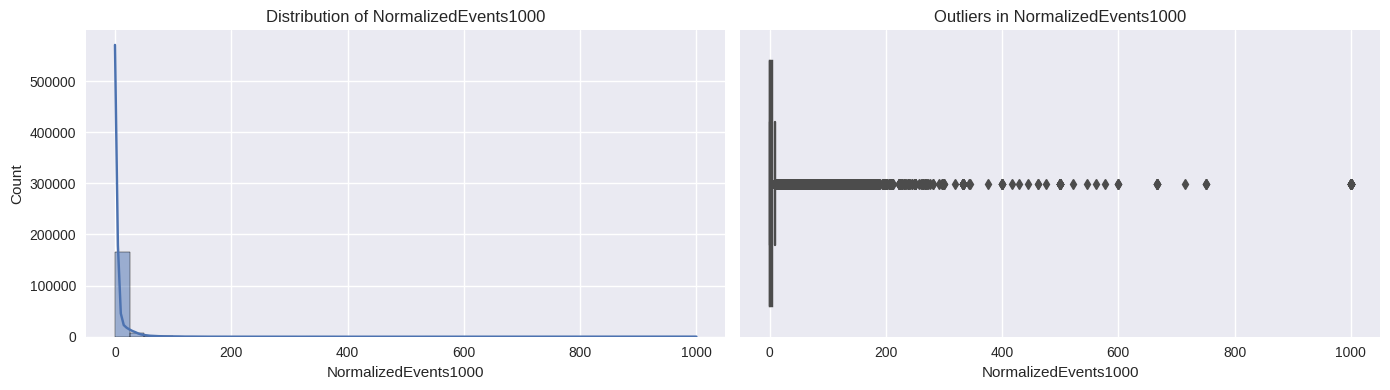

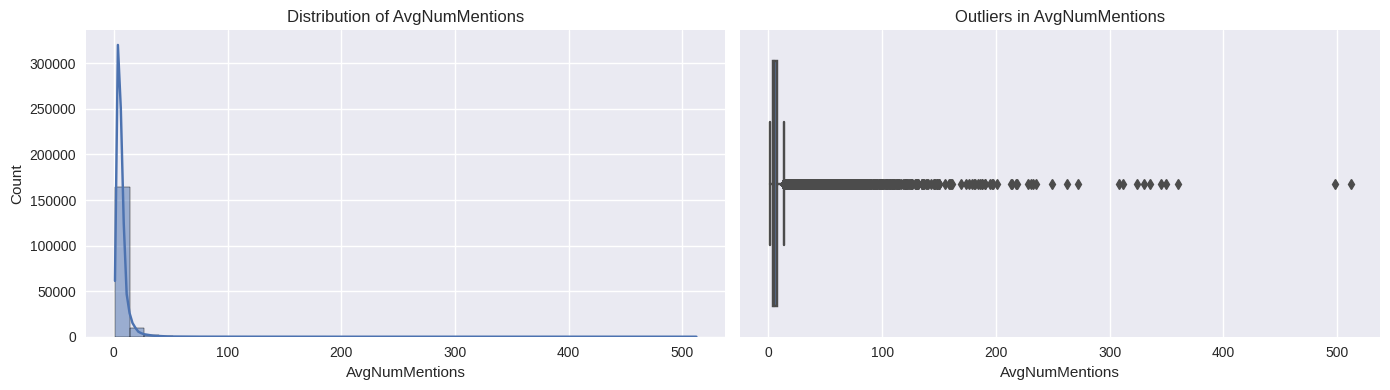

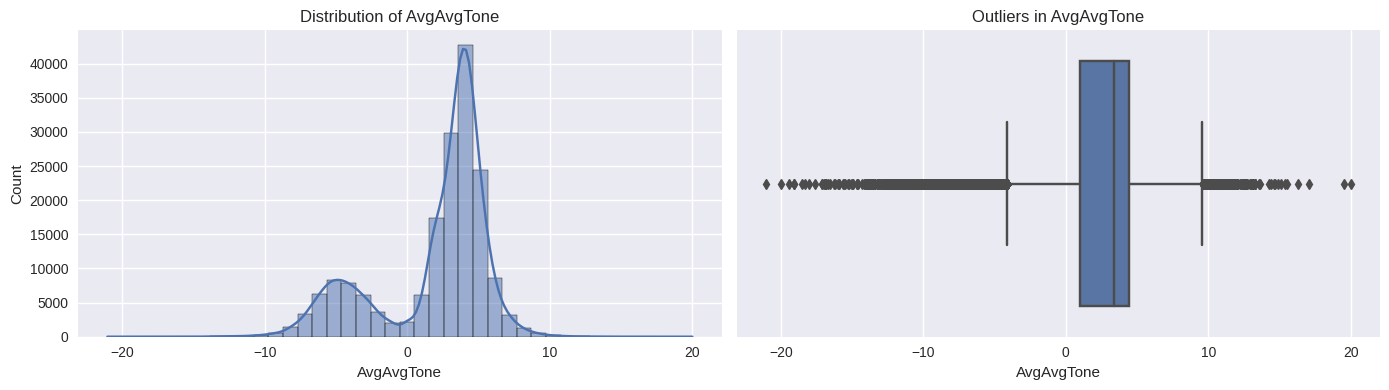

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#Ignore warnings for display purposes
import warnings
warnings.filterwarnings("ignore")

#Columns to visualize
cols_to_plot = [
    'NormalizedEvents1000',
    'AvgNumMentions',
    'AvgAvgTone'
]

plt.style.use('seaborn-v0_8')

for col in cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize = (14, 4))

    #Histograms + KDE curve
    sns.histplot(df[col].dropna(), kde = True, bins = 40, ax = axes[0])
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    #Boxplots
    sns.boxplot(x=df[col].dropna(), ax = axes[1])
    axes[1].set_title(f"Outliers in {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()
    plt.close()

When examining these continuous variables, the histograms and boxplots reveal the presence of multiple extreme values or outliers. These outliers are **not errors**; they reflect real phenomena, such as countries experiencing intense conflicts or receiving disproportionate media coverage. Rather than removing them, we **retain all values** to preserve the integrity of the dataset and ensure the analysis reflects real-world patterns.  

The presence of extreme values, however, causes **skewed distributions**, which can make visual interpretation difficult and violate the assumptions of parametric statistical tests. To address this, we apply appropriate transformations to reduce skewness, stabilize variance, and make the distributions more suitable for statistical analyses. After transformation, the distributions become easier to visualize, and the variables might be more appropriate for correlation analyses, regressions, and other parametric tests.  

We will apply these transformations to `NormalizedEvents1000` and `AvgNumMentions`, because `AvgAvgTone` clearly exhibits a bimodal distribution, which is not normal.

In [7]:
#Create a function to determine the best transformation for relevant columns
from scipy.stats import boxcox, yeojohnson
import numpy as np

def best_transformation(series):
    s = series.dropna()
    transformations = {}

    #Original
    original_skew = abs(skew(s))
    transformations["original"] = (original_skew, s)

    #Log (Not applicable for values below zero, included here for educational purposes)
    if (s >= 0).all():
        log_t = np.log1p(s)
        transformations["log"] = (abs(skew(log_t)), log_t)

    #Sqrt (Not applicable for values below zero, included here for educational purposes)
    if (s >= 0).all():
        sqrt_t = np.sqrt(s)
        transformations["sqrt"] = (abs(skew(sqrt_t)), sqrt_t)

    #Box-Cox
    if (s > 0).all():
        bc_t, _ = boxcox(s)
        transformations["boxcox"] = (abs(skew(bc_t)), bc_t)

    #Yeo-Johnson
    yj_t, _ = yeojohnson(s)
    transformations["yeojohnson"] = (abs(skew(yj_t)), yj_t)

    best_method = min(transformations, key=lambda m: transformations[m][0])
    transformed_skew, _ = transformations[best_method]

    return best_method, original_skew, transformed_skew

In [8]:
#Show results in a dataframe
final_cols_to_plot = cols_to_plot.copy()
final_cols_to_plot.remove('AvgAvgTone')

results = []

for col in final_cols_to_plot:
    method, orig, trans = best_transformation(df[col])
    results.append({
        "Column": col,
        "Best Method": method,
        "Original Skew": orig,
        "Transformed Skew": trans
    })

pd.DataFrame(results)

,Column,Best Method,Original Skew,Transformed Skew
0,NormalizedEvents1000,boxcox,21.852952,0.000089
1,AvgNumMentions,boxcox,15.366565,0.025249


In [9]:
#Create a copy of the dataframe to store transformed columns
df_transformed = df.copy()

#Apply Box-Cox transformation to the selected columns
for col in final_cols_to_plot:
    s = df[col].copy()
    
    #Box-Cox requires strictly positive values
    s_pos = s[s > 0]
    s_transformed, _ = boxcox(s_pos)
    s.loc[s_pos.index] = s_transformed
    
    df_transformed[col] = s

#Check the first rows of the transformed dataframe
df_transformed[final_cols_to_plot].head()

,NormalizedEvents1000,AvgNumMentions
0,2.340348,1.303528
1,2.968176,0.931962
2,2.464184,1.659265
3,3.116617,1.224047
4,1.604904,1.406991


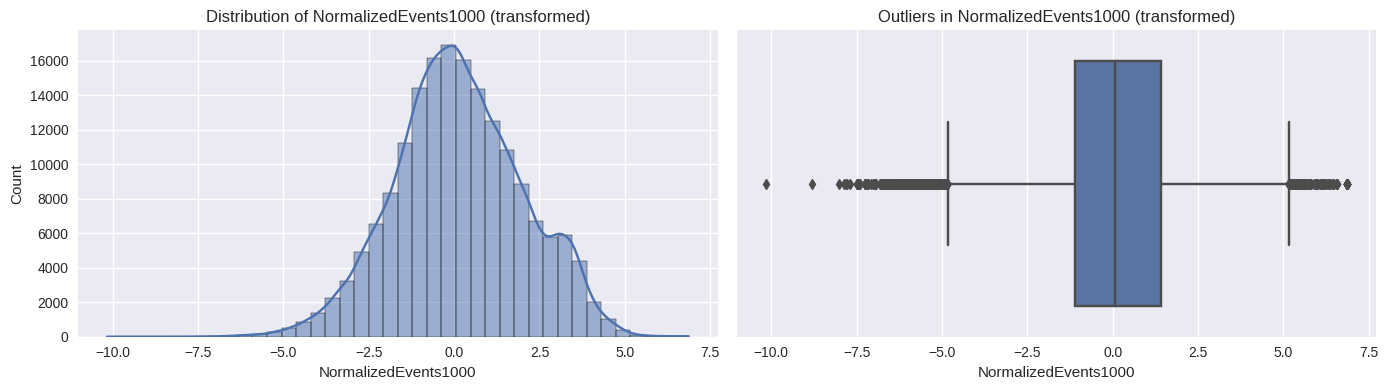

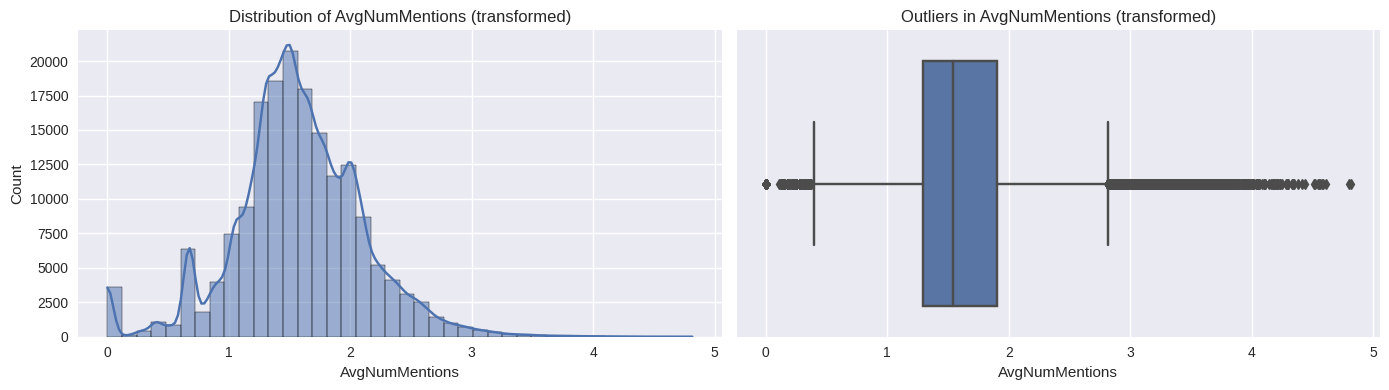

In [10]:
#Loop through transformed columns to visualize distributions
for col in final_cols_to_plot:
    transformed_col = df_transformed[col]
    
    fig, axes = plt.subplots(1, 2, figsize = (14, 4))

    #Histograms + KDE
    sns.histplot(transformed_col.dropna(), kde = True, bins = 40, ax = axes[0])
    axes[0].set_title(f"Distribution of {col} (transformed)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    #Boxplot to check outliers
    sns.boxplot(x = transformed_col.dropna(), ax = axes[1])
    axes[1].set_title(f"Outliers in {col} (transformed)")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()
    plt.close()

In [11]:
#List to store results
skew_kurt_results = []

#Loop through the transformed columns
for col in final_cols_to_plot:
    s = df_transformed[col].dropna()
    
    #Calculate skewness and kurtosis
    skew_val = skew(s)
    kurt_val = kurtosis(s)
    
    skew_kurt_results.append({
        "Column": col,
        "Skew": skew_val,
        "Kurtosis": kurt_val
    })

#Create dataframe
skew_kurt_df = pd.DataFrame(skew_kurt_results)

#Display the results
skew_kurt_df

,Column,Skew,Kurtosis
0,NormalizedEvents1000,0.000089,-0.079344
1,AvgNumMentions,-0.025249,1.354815


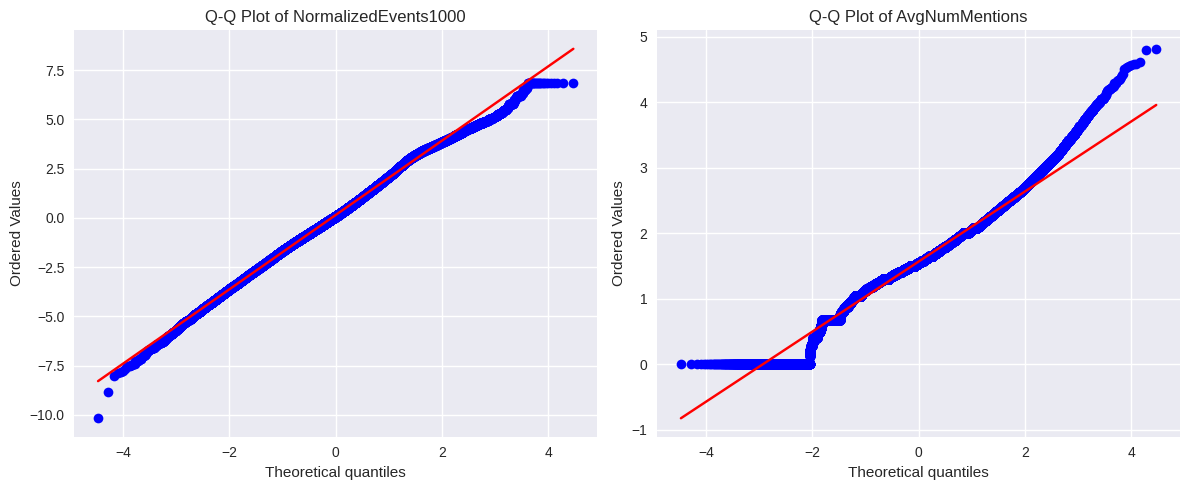

In [12]:
##Q-Q plots
import scipy.stats as stats

qq_cols = final_cols_to_plot

fig, axes = plt.subplots(1, len(qq_cols), figsize = (12, 5))

for i, col in enumerate(qq_cols):
    stats.probplot(df_transformed[col].dropna(), dist = "norm", plot = axes[i])
    axes[i].set_title(f"Q-Q Plot of {col}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

| Variable               | Visual Distribution                                      | Skewness/Kurtosis (post-transformation) | Outliers / Extreme Behavior                 | Approx. Normality                                |
|------------------------|----------------------------------------------------------|----------------------------------------|--------------------------------------------|-------------------------------------------------|
| NormalizedEvents1000   | Smooth bell-shaped distribution                          | Skew ≈ 0.00009, Kurt ≈ -0.079          | Few outliers                                | Normal                                          |
| AvgNumMentions         | Small peaks at 0 and 0.75, peak around 1.5, long right tail       | Skew ≈ -0.025, Kurt ≈ 1.355           | Long right tail                             | Approximately normal after Box-Cox             |
| AvgAvgTone             | Double peak (-4 and 6), long right tail                 | Skew ≈ -1.095, Kurt ≈ 0.28             | Marked right tail                            | Bimodal                             |

After transformation and Q-Q plot analysis, `NormalizedEvents1000` and `AvgNumMentions` show approximately normal distributions and are suitable for parametric tests.

## 1.3-Data Visualization and Transformation - Discrete Variables

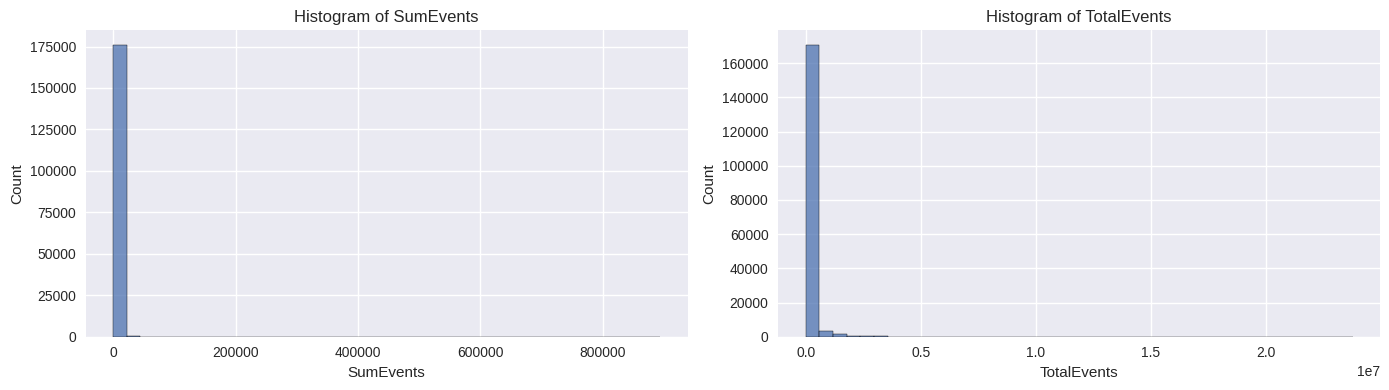

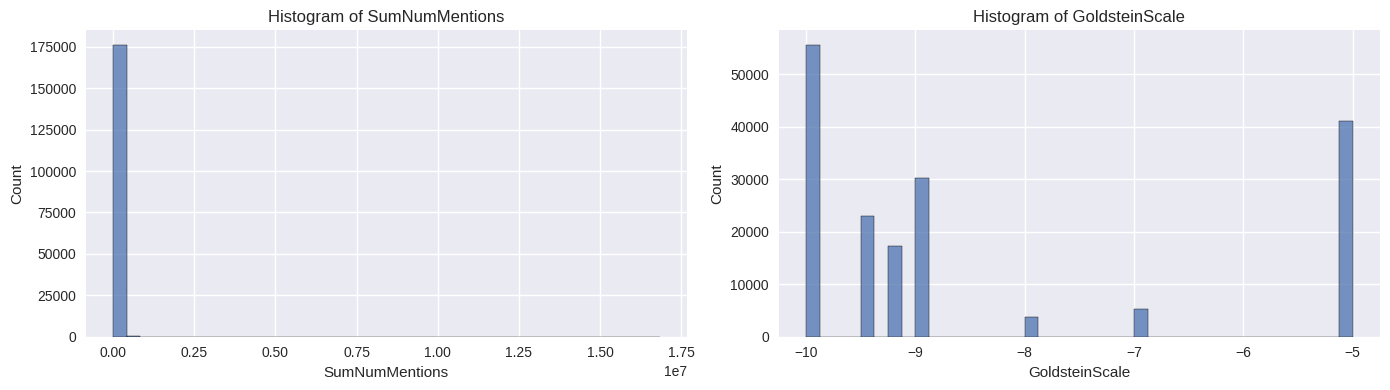

In [13]:
#List of discrete columns to analyze
discrete_cols = ['SumEvents', 'TotalEvents', 'SumNumMentions', 'GoldsteinScale']

plt.style.use('seaborn-v0_8')

#Loop over variables in chunks of 2
for i in range(0, len(discrete_cols), 2):
    fig, axes = plt.subplots(1, 2, figsize = (14,4))
    
    for j, col in enumerate(discrete_cols[i:i+2]):
        #Histograms
        sns.histplot(df[col].dropna(), bins = 40, kde = False, ax = axes[j])
        axes[j].set_title(f"Histogram of {col}")
        axes[j].set_xlabel(col)
        axes[j].set_ylabel("Count")
    
    plt.tight_layout()
    plt.show()

In [14]:
#Descriptive statistics : prepare a list to store results
desc_stats = []

for col in discrete_cols:
    s = df[col].dropna()
    desc_stats.append({
        "Column": col,
        "Count": s.count(),                 # Number of non-missing values
        "Min": s.min(),                     # Minimum value
        "Max": s.max(),                     # Maximum value
        "Mean": s.mean(),                   # Mean
        "Median": s.median(),               # Median
        "Mode": s.mode().iloc[0],           # Most frequent value
        "Variance": s.var(),                # Variance
        "Std Dev": s.std(),                 # Standard deviation
        "Skewness": skew(s),                # Skewness
        "Kurtosis": kurtosis(s)             # Kurtosis
    })

#Create a dataframe to display
desc_stats_df = pd.DataFrame(desc_stats)

#Display results
desc_stats_df

,Column,Count,Min,Max,Mean,Median,Mode,Variance,Std Dev,Skewness,Kurtosis
0,SumEvents,176432,1.0,893895.0,475.137237,13.0,1.0,7.244873e+07,8511.682202,69.018803,5722.543394
1,TotalEvents,176432,1.0,23770347.0,120847.038445,16483.0,21821.0,6.840383e+11,827066.080693,20.950551,495.016346
2,SumNumMentions,176432,1.0,16834208.0,5985.703580,71.0,9.0,1.997519e+10,141333.620026,79.446717,7399.551749
3,GoldsteinScale,176432,-10.0,-5.0,-8.385991,-9.2,-10.0,3.845948e+00,1.961109,0.998471,-0.758676


To improve the visualization of highly skewed discrete numeric variables (excluding `GoldsteinScale`), we apply a **logarithmic transformation (log(x + 1))**. This transformation compresses the long right tails, making the distribution of the majority of smaller values more visible, while preserving the order of the data. It is important to note that this transformation is used **only for visualization purposes** and does not alter the original data for descriptive statistics or further analyses.

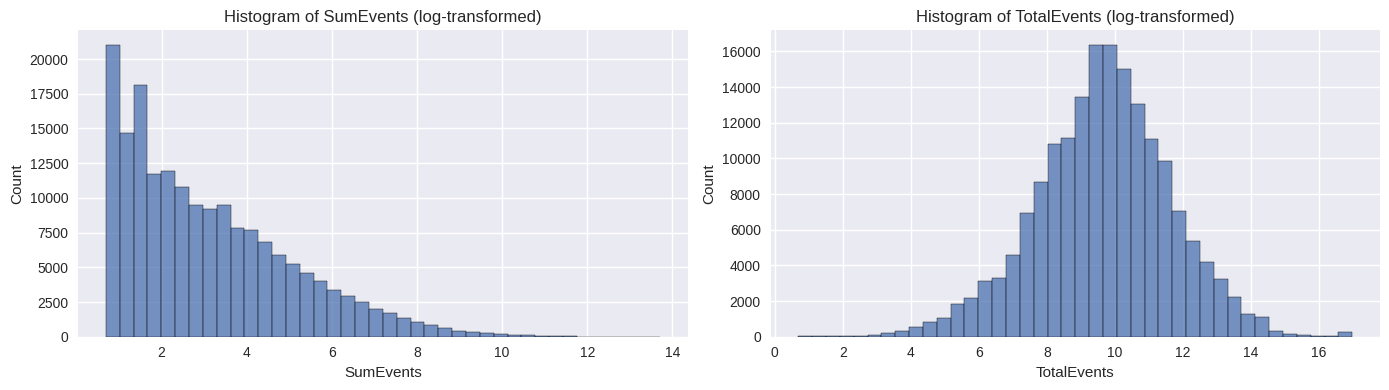

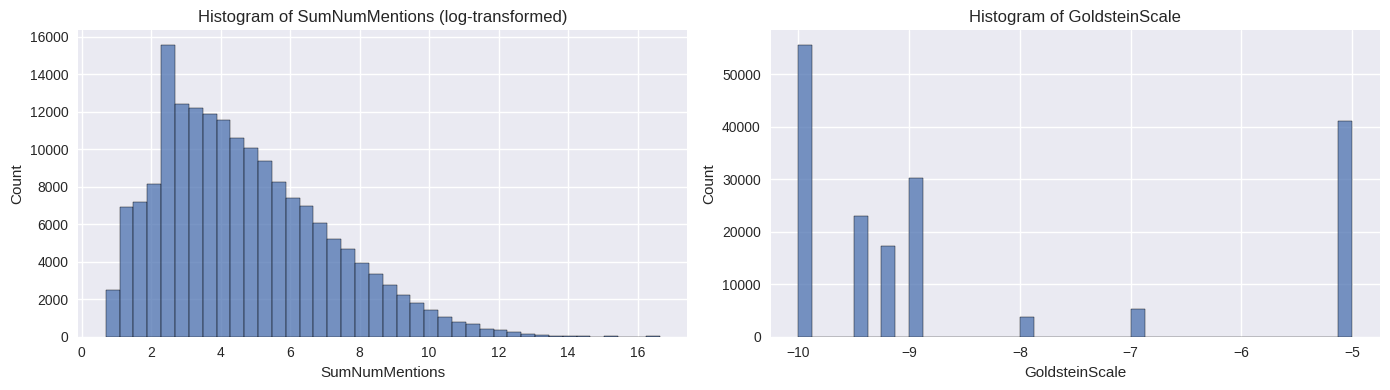

In [15]:
plt.style.use('seaborn-v0_8')

#Loop over variables in chunks of 2
for i in range(0, len(discrete_cols), 2):
    fig, axes = plt.subplots(1, 2, figsize = (14,4))
    
    for j, col in enumerate(discrete_cols[i:i+2]):
        data = df[col].dropna()
        
        #Apply log(x+1) transformation only if not GoldsteinScale
        if col != 'GoldsteinScale':
            data = np.log1p(data)
        
        #Histograms with log-transformed columns
        sns.histplot(data, bins = 40, kde = False, ax = axes[j])
        axes[j].set_title(f"Histogram of {col}" + (" (log-transformed)" if col != 'GoldsteinScale' else ""))
        axes[j].set_xlabel(col)
        axes[j].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

The discrete numeric variables `SumEvents`, `TotalEvents`, and `SumNumMentions` are highly skewed, with extreme values dominating their raw distributions. To improve visual interpretability, **logarithmic transformation (log(x + 1))** was applied to these variables.

- **SumEvents:** Most observations are very low, while a few extreme events dominate the raw distribution. After log-transformation, the histogram shows a **clear peak for the most common values**, with extreme values compressed but still visible. This allows a better understanding of the **typical number of events per country-year** without losing information about high-event outliers.

- **TotalEvents:** Originally extremely skewed, the log-transformation compresses very large totals and slightly spreads low totals. The resulting histogram forms a **bell-shaped curve**, indicating that most country-year totals cluster around a central value (near the median), while very large totals remain rare but visible. Concretely, this shows that **most countries/years experience moderate totals**, and the transformation makes this central tendency visually clear.

- **SumNumMentions:** The majority of events have few mentions, while a small number receive extremely high media coverage. The log-transformed histogram emphasizes the **typical coverage pattern**, compressing extreme mentions but clearly showing the bulk of observations.

- **GoldsteinScale:** Values are concentrated at the extreme negative end, mostly around -9 to -10, or closer to -5, with very few observations in between. This reflects that most events are associated with **strong negative (conflict-related) impacts**, with fewer moderate-scale events. No transformation was applied since the variable is already bounded and not highly skewed in a way that distorts visual interpretation.

**Key takeaway:** The log-transformation is **used purely for visualization purposes**, preserving the order and relative differences between observations, compressing extreme values, and enhancing readability of distributions spanning multiple orders of magnitude.

## 1.4-Data Visualization and Transformation - Categorical Variables

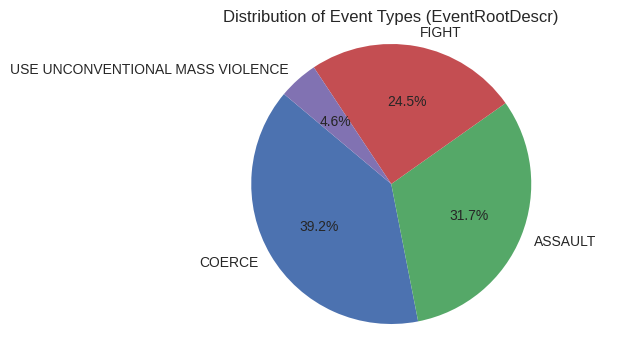

In [16]:
#Count occurrences of each category
event_counts = df['EventRootDescr'].value_counts()

#Create the pie chart
plt.figure(figsize=(6,4))
plt.pie(
    event_counts,                # values
    labels=event_counts.index,   # category labels
    autopct='%1.1f%%',           # display percentages
    startangle=140,              # starting angle
)

plt.title('Distribution of Event Types (EventRootDescr)')
plt.axis('equal')
plt.show()

In [17]:
#Sum of events per year
events_per_year = df.groupby('Year')['SumEvents'].sum().reset_index()

#Rename columns
events_per_year.columns = ['Year', 'TotalEvents']

#Display
events_per_year

,Year,TotalEvents
0,1979,41454
1,1980,64878
2,1981,85421
3,1982,101142
4,1983,113774
5,1984,119871
6,1985,136185
7,1986,139007
8,1987,135084
9,1988,142344


In [18]:
#Count occurrences of each country
top_countries = df['CountryName'].value_counts().head(10)

#Display the top 10 countries
top_countries

CountryName
United States     1414
Israel            1401
United Kingdom    1361
Russia            1356
Iran              1339
India             1321
France            1317
Iraq              1302
China             1300
Pakistan          1298
Name: count, dtype: int64

In [19]:
#Count the number of events for each GoldsteinScale value
goldstein_counts = df['GoldsteinScale'].value_counts().sort_index()

#Display the counts
goldstein_counts

GoldsteinScale
-10.0    55610
-9.5     22971
-9.2     17347
-9.2        26
-9.0     30285
-8.0      3717
-7.0      5360
-5.0     41116
Name: count, dtype: int64

In [20]:
#Count occurrences of each unique event description
event_descr_counts = df['EventDescr'].value_counts().reset_index()

#Rename columns for clarity
event_descr_counts.columns = ['EventDescr', 'Count']

#Display
event_descr_counts

,EventDescr,Count
0,"Use conventional military force, not specified...",9168
1,"Arrest, detain, or charge with legal action",9149
2,"Impose administrative sanctions, not specified...",8271
3,Fight with small arms and light weapons,8106
4,Occupy territory,7775
5,"Use unconventional violence, not specified below",7562
6,Expel or deport individuals,7016
7,"Physically assault, not specified below",6649
8,"Abduct, hijack, or take hostage",6636
9,Assassinate,6623


## 1.5-Summary and Limitations

This first notebook focused on exploring and preparing the global conflict events dataset (1979–2021). The dataset was clean, complete, and included 176,432 records covering countries, years, event types (CAMEO codes), event severity (GoldsteinScale), media mentions, and media tone.

**Continuous variables** (NormalizedEvents1000, AvgNumMentions) were highly skewed due to extreme events; Box-Cox transformations normalized them for statistical analyses, while AvgAvgTone was bimodal and retained untransformed. Due to the very large sample size (over 176,000 observations), classical normality tests for continuous variables, such as the Anderson-Darling and Kolmogorov-Smirnov tests, were not applied, as they become overly sensitive and less reliable with such large datasets.

**Discrete variables** (SumEvents, TotalEvents, SumNumMentions) were log-transformed to improve visualization of their highly skewed distributions, compressing extreme values while preserving the order of observations (solely for visualization purposes at the moment).

**Categorical** variables were counted and visualized to highlight dominant event types (COERCE, ASSAULT, FIGHT) and the top countries. Temporal aggregation revealed increasing conflict activity over decades with peaks corresponding to major geopolitical events.

**Limitations:**

- Extreme values and skewed distributions may bias statistical summaries if not transformed.
- Media mentions and tone may not fully reflect actual conflict severity, introducing reporting bias.
- The dataset covers only recorded events; unreported or minor events are missing.
- Some categorical codes (rare event types) are underrepresented, limiting generalization.

Overall, this notebook provides a robust descriptive foundation, identifying patterns, distributions, and necessary transformations, while highlighting areas where data limitations should be considered in subsequent analyses. 

By keeping the main research questions in mind (examining the most frequent conflict types and their evolution, understanding the relationship between conflict severity and media coverage, and identifying the most affected countries and regions) these summaries and preparations ensure that the next steps remain focused, targeted, and aligned with the objectives outlined in the introduction.

## 1.6-Export dataset

In [21]:
# Export du dataframe transformé directement
export_path = "global_conflict_full_boxcox.csv"
df_transformed.to_csv(export_path, index=False)

print(f"Full dataset exported to '{export_path}'")

Full dataset exported to 'global_conflict_full_boxcox.csv'
